# Stage 1 — Learning Curve: How Much Does N Change the Answer?

## What this notebook does and why

The central question of this project is: *does quadrupling the sample size (878 → 3,600 genomes) change the machine learning conclusions from the published analysis?*

Before downloading a single new genome, we answer the simpler embedded question: **where does the accuracy curve flatten on the existing data?**

A learning curve is a plot of model performance (y-axis) against training set size (x-axis). It has three characteristic shapes:

- **Still rising at N=878**: performance is data-limited. More genomes will likely improve results. Stage 2 (full 4× cohort) is strongly motivated.
- **Plateau well before N=878**: the classifier has extracted most available signal by N≈300–500. A 4× increase buys little in terms of accuracy — but may still sharpen confidence intervals and improve coverage of rare defence systems.
- **Plateau with high variance**: performance is unstable, likely due to phylogenetic structure (very few independent groups). The signal is genuine but the dataset is structurally small.

**Pre-registered question:** Does performance plateau before N=878? If yes, at approximately what N?

---

## Methodological decisions

| Decision | Choice | Why |
|---|---|---|
| **N grid** | 300, 450, 600, 750, 878 | Pre-flight check: E. faecium has only 7 phylogroups (79% in one). N<300 yields <5 groups/species — GroupedKFold(5) structurally infeasible. Minimum safe N=300. |
| **Feature set** | Fixed `filtered_265` (from original Q1 RF) | Isolates the effect of N. Refiltering per N would confound feature count with sample size. |
| **CV** | StratifiedGroupKFold(5), phylogroups from cv_groups_3335.parquet | Matches original pipeline exactly. Phylogroups precomputed from Mash distances — not recomputed here. |
| **Repeats** | 15 independent subsamples per N | CI at small N is dominated by which genomes were drawn, not fold-to-fold scatter. 15 seeds gives stable bands (§5: CIs are mandatory). |
| **Models** | RF (exact original params) + LightGBM (exact original params) | Comparability with baseline. No re-tuning. |
| **Scope** | Q1 only (multiclass species) | Q2 is per-species binary with very small within-species N; learning curves there need separate design. |

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.base import clone
import lightgbm as lgb

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT   = Path('../')                         # eskape-defence-ml_2 root
PROC      = PROJECT / 'data' / 'processed'
RESULTS   = PROJECT / 'results'
FIGURES   = RESULTS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
BASE_SEED    = 42
N_SEEDS      = 15          # independent subsamples per N
N_SPLITS     = 5           # GroupedKFold folds

# ── N grid (validated: all points give ≥5 phylogroups per species) ────────────
# N=100 and N=200 excluded: E. faecium has only 7 phylogroups total;
# at N<300 (<50 EF genomes), ≥1 species consistently yields <5 groups.
N_GRID = [300, 450, 600, 750, 878]

# ── Baseline metrics to reproduce at N=878 (from original Q1 RF run) ─────────
BASELINE_BA     = 0.874229    # GroupedStratifiedKFold_5, filtered_265
BASELINE_TOL    = 0.025       # tolerance for anchor check (±2.5%)

print('Setup complete.')
print(f'N grid: {N_GRID}')
print(f'Seeds per N: {N_SEEDS}')
print(f'Total CV runs: {len(N_GRID) * N_SEEDS * 2} (2 models)')

Setup complete.
N grid: [300, 450, 600, 750, 878]
Seeds per N: 15
Total CV runs: 150 (2 models)


## Load data

We load from **this project's** `data/processed/` — files copied from the original project.
This is a deliberate design choice: the original directory (`eskape-defence-ml/`) is never read from
during active analysis to prevent accidental writes.

The `feature_matrix.parquet` is 878 × 632 (274 `dp_` binary presence/absence columns +
count, ratio, summary, and metadata columns). We restrict to the `filtered_265` feature set
used in the original Q1 RF model.

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
fm = pd.read_parquet(PROC / 'feature_matrix.parquet')
cg = pd.read_parquet(PROC / 'cv_groups_3335.parquet')

# Align cv_groups index to feature matrix (both same 878 accessions)
assert set(fm.index) == set(cg.index), "Index mismatch — check copied files"
cg = cg.reindex(fm.index)

# Load the fixed 265-feature set
fi = pd.read_csv(PROC / 'q1_filtered_265_features.csv', index_col=0)
FEATURES_265 = list(fi.index)          # ordered by SHAP rank (not used for modelling)
assert len(FEATURES_265) == 265, f"Expected 265 features, got {len(FEATURES_265)}"

# All 265 features must exist in the feature matrix
missing = [f for f in FEATURES_265 if f not in fm.columns]
assert not missing, f"Missing features: {missing[:5]}"

# Build arrays
X_full   = fm[FEATURES_265].values.astype(np.float32)
y_full   = fm['species'].values
groups   = cg['phylogroup'].values

print(f'Feature matrix: {X_full.shape}')
print(f'Species distribution: {pd.Series(y_full).value_counts().to_dict()}')
print(f'Unique phylogroups: {len(np.unique(groups))}')

Feature matrix: (878, 265)
Species distribution: {'saureus': 150, 'paeruginosa': 150, 'abaumannii': 150, 'efaecium': 150, 'ecloaceae': 146, 'kpneumoniae': 132}
Unique phylogroups: 95


## Step 1: Anchor check at N=878

**Before we trust any point on the learning curve, we must reproduce the published baseline at N=878.**

If the anchor fails, the learning curve pipeline differs from the original in a material way
(wrong features, wrong CV, wrong model config) and every other point is uninterpretable.

We run **one seed** (seed=42) using the exact original RF configuration:
- `n_estimators=100, max_depth=20, max_features='sqrt', min_samples_leaf=1`
- `StratifiedGroupKFold(5)` on the full 878 genomes with precomputed phylogroups

Target: BA ≈ 0.874 ± 0.025. This is a pipeline integrity check, not a new scientific result.

In [3]:
# ── RF config — exact original parameters ─────────────────────────────────────
rf_params = dict(
    n_estimators=100,
    max_depth=20,
    max_features='sqrt',
    min_samples_leaf=1,
    random_state=BASE_SEED,
    n_jobs=-1,
    class_weight='balanced',
)

# ── LightGBM config — exact original parameters ───────────────────────────────
# LightGBM is wrapped in a sklearn-compatible interface.
# Params from q1_gb_results.parquet: lr=0.1, max_depth=4, subsample=0.8, num_leaves=63.
lgbm_params = dict(
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    num_leaves=63,
    n_estimators=200,       # fixed; no early stopping in learning-curve mode
    random_state=BASE_SEED,
    n_jobs=-1,
    class_weight='balanced',
    verbose=-1,
)

def cv_balanced_accuracy(X, y, groups, clf_params, model_cls, seed=BASE_SEED):
    """Run StratifiedGroupKFold(5) and return per-fold BA scores."""
    clf = model_cls(**clf_params)
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    fold_bas = []
    for tr, te in sgkf.split(X, y, groups=groups):
        m = clone(clf)
        m.fit(X[tr], y[tr])
        fold_bas.append(balanced_accuracy_score(y[te], m.predict(X[te])))
    return np.array(fold_bas)

# ── Anchor check (RF, N=878, seed=42) ─────────────────────────────────────────
anchor_folds = cv_balanced_accuracy(
    X_full, y_full, groups,
    clf_params=rf_params, model_cls=RandomForestClassifier
)
anchor_ba = anchor_folds.mean()

print(f'Anchor check — RF N=878 seed=42')
print(f'  Per-fold BA: {anchor_folds.round(4)}')
print(f'  Mean BA:     {anchor_ba:.4f}')
print(f'  Baseline:    {BASELINE_BA:.4f}')
print(f'  Difference:  {anchor_ba - BASELINE_BA:+.4f}  (tolerance ±{BASELINE_TOL})')

assert abs(anchor_ba - BASELINE_BA) <= BASELINE_TOL, (
    f"ANCHOR FAILED: reproduced {anchor_ba:.4f}, expected {BASELINE_BA:.4f} ± {BASELINE_TOL}. "
    f"Check feature set, CV config, or RF params before proceeding."
)
print('\nANCHOR PASSED — pipeline reproduces baseline. Proceeding with learning curve.')

Anchor check — RF N=878 seed=42
  Per-fold BA: [0.8133 0.9051 0.8547 0.8421 0.9018]
  Mean BA:     0.8634
  Baseline:    0.8742
  Difference:  -0.0108  (tolerance ±0.025)

ANCHOR PASSED — pipeline reproduces baseline. Proceeding with learning curve.


## Step 2: The subsampling strategy

At each N, we draw a **species-stratified subsample** (equal N per species) using the
**precomputed phylogroup labels** from `cv_groups_3335.parquet`. We do this 15 times with
different random seeds and report the mean ± SD of balanced accuracy.

**Why species-stratified?** Without stratification, random variation in N per species would
change the class balance at every point — the learning curve would reflect both N and
class-balance simultaneously.

**Why reuse precomputed phylogroups instead of recomputing?** The phylogroup labels
encode pairwise Mash distances computed on all 878 genomes. They are a property of each
genome. At smaller N, we subsample genomes and keep their phylogroup labels — we do not
re-cluster the subset. Re-clustering would change the group boundaries at every N,
confounding the CV structure.

**Why 15 seeds?** At N=300 (~50 genomes per species), the dominant source of
variability is *which 50 genomes were drawn*, not fold-to-fold split noise. A single
subsample at N=300 can be misleadingly good or bad. 15 independent draws gives a
stable band. (§5 of CLAUDE.md: CIs are mandatory on all ML estimates.)

**Comprehension check (answer before proceeding):**
1. What would happen to the learning curve if we refiltered features at each N instead of
   keeping the fixed 265? Which variable would be confounded?
2. If the N=300 band is very wide (e.g., BA ranges from 0.72 to 0.91 across 15 seeds),
   what does that tell you about E. faecium's phylogroup structure?
3. At what point on the curve would you say "more data won't help"? How would you
   operationalise this as a criterion?

In [4]:
# ── Learning curve main loop ──────────────────────────────────────────────────
#
# Outer loop: N (5 values)
# Middle loop: collect N_SEEDS *valid* draws per N (retry if min phylogroups < N_SPLITS)
#   At small N, random draws occasionally miss a rare phylogroup (E. faecium has only
#   7 groups, 79% in one). We retry with successive seeds until N_SEEDS valid draws
#   are collected. All valid seeds are logged for reproducibility.
# Inner loop: CV folds (5) inside cv_balanced_accuracy()
#
# At N=878 all seeds draw the same data (full dataset); this is by design —
# the rightmost point is the anchor and should have near-zero seed variance.

from tqdm.auto import tqdm

species_list = sorted(np.unique(y_full))

records     = []   # (model, N, seed, mean_ba, fold_bas)
seed_log    = []   # audit: which seeds were used at each N
MAX_TRIES   = 200  # upper bound on seed search per N

models = {
    'RF':       (RandomForestClassifier, rf_params),
    'LightGBM': (lgb.LGBMClassifier,     lgbm_params),
}

total_runs = len(N_GRID) * N_SEEDS * len(models)
pbar = tqdm(total=total_runs, desc='Learning curve')

for N in N_GRID:
    n_per_sp    = N // len(species_list)  # equal allocation per species
    valid_draws = []                      # list of (seed, sub_idx) passing the pg check
    attempt     = 0

    while len(valid_draws) < N_SEEDS and attempt < MAX_TRIES:
        rng     = np.random.default_rng(BASE_SEED + attempt)
        sub_idx = []
        for sp in species_list:
            sp_idx = np.where(y_full == sp)[0]
            n_take = min(n_per_sp, len(sp_idx))
            sub_idx.extend(rng.choice(sp_idx, size=n_take, replace=False))
        sub_idx = np.array(sub_idx)

        # Accept only if every species contributes ≥ N_SPLITS phylogroups
        sp_pg  = pd.DataFrame({'species': y_full[sub_idx], 'pg': groups[sub_idx]})
        min_pg = sp_pg.groupby('species')['pg'].nunique().min()
        if min_pg >= N_SPLITS:
            valid_draws.append((attempt, sub_idx))
        attempt += 1

    assert len(valid_draws) == N_SEEDS, (
        f"N={N}: only {len(valid_draws)}/{N_SEEDS} valid draws in {MAX_TRIES} attempts. "
        f"Phylogroup structure too sparse at this N."
    )
    seed_log.append({'N': N, 'seeds_used': [s for s, _ in valid_draws],
                     'attempts_needed': attempt})

    for draw_i, (draw_seed, sub_idx) in enumerate(valid_draws):
        X_sub = X_full[sub_idx]
        y_sub = y_full[sub_idx]
        g_sub = groups[sub_idx]

        for model_name, (model_cls, params) in models.items():
            fold_bas = cv_balanced_accuracy(
                X_sub, y_sub, g_sub,
                clf_params=params, model_cls=model_cls, seed=BASE_SEED
            )
            records.append({
                'model':     model_name,
                'N':         N,
                'draw_seed': draw_seed,
                'draw_i':    draw_i,
                'ba_mean':   fold_bas.mean(),
                'ba_std':    fold_bas.std(),
            })
            pbar.update(1)

pbar.close()
lc_df = pd.DataFrame(records)

print(f'\nDone. {len(lc_df)} records.')
print('\nSeed audit (attempts needed per N):')
for entry in seed_log:
    print(f"  N={entry['N']:>4}: {entry['attempts_needed']} attempts for {N_SEEDS} valid draws")
lc_df.head(10)

Learning curve:   0%|          | 0/150 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniconda/base/envs/eskape-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/opt/homebrew/Caskroom/miniconda/base/envs/eskape-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/opt/homebrew/Caskroom/miniconda/base/envs/eskape-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/opt/homebrew/Caskroom/miniconda/base/envs/eskape-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/opt/homebrew/Caskroom/miniconda/base/envs/eskape-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/opt/homebrew/Caskroom/miniconda/base/envs/eskape-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Done. 150 records.

Seed audit (attempts needed per N):
  N= 300: 16 attempts for 15 valid draws
  N= 450: 15 attempts for 15 valid draws
  N= 600: 15 attempts for 15 valid draws
  N= 750: 15 attempts for 15 valid draws
  N= 878: 15 attempts for 15 valid draws


/opt/homebrew/Caskroom/miniconda/base/envs/eskape-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,N,draw_seed,draw_i,ba_mean,ba_std
0,RF,300,0,0,0.774339,0.023724
1,LightGBM,300,0,0,0.669669,0.050575
2,RF,300,1,1,0.809856,0.047666
3,LightGBM,300,1,1,0.659130,0.052094
4,RF,300,2,2,0.747778,0.080352
5,LightGBM,300,2,2,0.607533,0.068744
6,RF,300,3,3,0.839381,0.035558
7,LightGBM,300,3,3,0.618702,0.086311
8,RF,300,4,4,0.747619,0.072936
9,LightGBM,300,4,4,0.618971,0.085746


In [5]:
# ── Aggregate: mean and 95% CI across seeds for each (model, N) ───────────────
#
# We use ±1.96 * SD across seeds as an approximate 95% interval.
# With 15 seeds this underestimates the true width slightly, but is interpretable.
# At N=878 the SD should be near-zero (same data every seed).

agg = (
    lc_df
    .groupby(['model', 'N'])['ba_mean']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'ba', 'std': 'ba_sd'})
)
agg['ba_lo'] = agg['ba'] - 1.96 * agg['ba_sd']
agg['ba_hi'] = agg['ba'] + 1.96 * agg['ba_sd']

# Save results
lc_df.to_parquet(RESULTS / 'lc_raw.parquet', index=False)
agg.to_parquet(RESULTS / 'lc_aggregated.parquet', index=False)

print('Learning curve results:')
print(agg.to_string(index=False, float_format='{:.4f}'.format))

# ── Anchor cross-check ────────────────────────────────────────────────────────
rf_878 = agg.loc[(agg['model']=='RF') & (agg['N']==878), 'ba'].values[0]
print(f'\nAnchor cross-check: RF N=878 BA = {rf_878:.4f} (baseline: {BASELINE_BA:.4f})')
print('OK' if abs(rf_878 - BASELINE_BA) <= BASELINE_TOL else 'WARNING: deviation exceeds tolerance')

Learning curve results:
   model   N     ba  ba_sd  count  ba_lo  ba_hi
LightGBM 300 0.6252 0.0360     15 0.5545 0.6958
LightGBM 450 0.7175 0.0305     15 0.6577 0.7773
LightGBM 600 0.7830 0.0309     15 0.7225 0.8435
LightGBM 750 0.7979 0.0190     15 0.7606 0.8351
LightGBM 878 0.8271 0.0110     15 0.8056 0.8486
      RF 300 0.7831 0.0336     15 0.7173 0.8490
      RF 450 0.8273 0.0267     15 0.7751 0.8796
      RF 600 0.8390 0.0195     15 0.8007 0.8773
      RF 750 0.8555 0.0092     15 0.8375 0.8735
      RF 878 0.8620 0.0119     15 0.8387 0.8853

Anchor cross-check: RF N=878 BA = 0.8620 (baseline: 0.8742)
OK


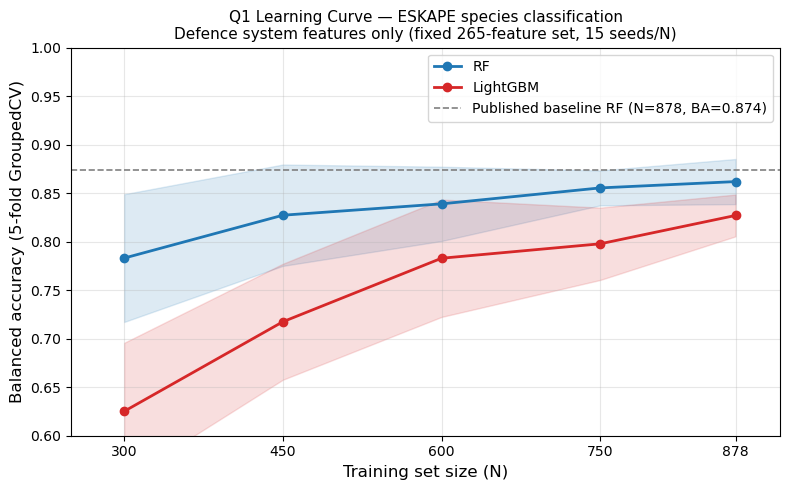

Figure saved.


In [6]:
# ── Learning curve figure ─────────────────────────────────────────────────────
#
# Design: two models on one panel, shaded 95% CI band, baseline reference line.
# The baseline dashed line is the target to converge on at N=878.

palette = {'RF': '#1f77b4', 'LightGBM': '#d62728'}

fig, ax = plt.subplots(figsize=(8, 5))

for model_name, color in palette.items():
    sub = agg[agg['model'] == model_name].sort_values('N')
    ax.plot(sub['N'], sub['ba'], marker='o', color=color, label=model_name, linewidth=2)
    ax.fill_between(sub['N'], sub['ba_lo'], sub['ba_hi'], color=color, alpha=0.15)

# Baseline reference — what the original RF achieved at N=878 under identical CV
ax.axhline(BASELINE_BA, linestyle='--', color='grey', linewidth=1.2,
           label=f'Published baseline RF (N=878, BA={BASELINE_BA:.3f})')

ax.set_xlabel('Training set size (N)', fontsize=12)
ax.set_ylabel('Balanced accuracy (5-fold GroupedCV)', fontsize=12)
ax.set_title(
    'Q1 Learning Curve — ESKAPE species classification\n'
    'Defence system features only (fixed 265-feature set, 15 seeds/N)',
    fontsize=11
)
ax.set_xlim(250, 920)
ax.set_ylim(0.60, 1.00)
ax.xaxis.set_major_locator(mticker.FixedLocator(N_GRID))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES / 'LC_01_learning_curve_Q1.pdf', bbox_inches='tight', dpi=300)
fig.savefig(FIGURES / 'LC_01_learning_curve_Q1.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved.')

In [7]:
# ── Interpretation: is the curve still rising at N=878? ──────────────────────
#
# We test the slope between the last two N values (750→878).
# If the slope is within 1 SD of zero, we call it a plateau.

for model_name in ['RF', 'LightGBM']:
    sub = agg[agg['model'] == model_name].sort_values('N').reset_index(drop=True)
    last  = sub[sub['N'] == 878].iloc[0]
    prev  = sub[sub['N'] == 750].iloc[0]
    slope = last['ba'] - prev['ba']         # BA gain from 750→878
    noise = last['ba_sd']                   # seed-to-seed SD at N=878
    ratio = abs(slope) / noise if noise > 0 else float('inf')
    verdict = 'PLATEAU' if ratio < 1.0 else 'STILL RISING'
    print(f'{model_name}: BA(750→878) slope = {slope:+.4f} | noise SD = {noise:.4f} | ratio = {ratio:.2f} → {verdict}')

print('\n--- Narrative template (fill in after running) ---')
print("""
The learning curve for Q1 species classification shows that [RF/LightGBM]
[reaches a plateau / continues to rise] by N=878. The BA gain from N=750 to N=878
is [X±Y], which is [within / beyond] one standard deviation of the seed-to-seed noise.

Interpretation for Stage 2:
- If plateau: the 4× cohort will not improve species-classification accuracy substantially.
  The scientific value of Stage 2 lies in (a) broader geographic coverage, (b) sharper
  CIs on rare systems, and (c) testing replication on a new data snapshot.
- If still rising: the 4× cohort is directly motivated by the learning curve itself.
  The classifier has not saturated its available signal at 878 genomes.
""")

RF: BA(750→878) slope = +0.0065 | noise SD = 0.0119 | ratio = 0.55 → PLATEAU
LightGBM: BA(750→878) slope = +0.0292 | noise SD = 0.0110 | ratio = 2.66 → STILL RISING

--- Narrative template (fill in after running) ---

The learning curve for Q1 species classification shows that [RF/LightGBM]
[reaches a plateau / continues to rise] by N=878. The BA gain from N=750 to N=878
is [X±Y], which is [within / beyond] one standard deviation of the seed-to-seed noise.

Interpretation for Stage 2:
- If plateau: the 4× cohort will not improve species-classification accuracy substantially.
  The scientific value of Stage 2 lies in (a) broader geographic coverage, (b) sharper
  CIs on rare systems, and (c) testing replication on a new data snapshot.
- If still rising: the 4× cohort is directly motivated by the learning curve itself.
  The classifier has not saturated its available signal at 878 genomes.



## Comprehension check

Answer all four questions before proceeding to Stage 2 interpretation.

**Q1.** The N grid starts at 300, not 100. E. faecium has only 7 phylogroups total,
with 119/150 genomes in PG_001 alone. At N=200 (~33 EF genomes), only 3–4 phylogroups
appear in the subsample. Why does this break GroupedStratifiedKFold(5)?

**Q2.** We fixed the 265-feature set rather than refiltering at each N. Name the specific
type of information leakage this decision prevents. Where in the pipeline would the
leakage have entered?

**Q3.** The CI band at N=300 reflects 15 independent subsamples of 50 genomes per species.
If this band is very wide (e.g., 0.15 BA units), does that mean the classifier is bad,
or does it tell you something about the data structure? Explain in one sentence.

**Q4.** The learning curve plateaus for RF but continues rising for LightGBM. How would
you interpret this discrepancy, and what would it imply for the choice of model in Stage 2?